#PART 1


================ FIRST FIVE ROWS ================

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

================ DATA TYPES ================

survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch

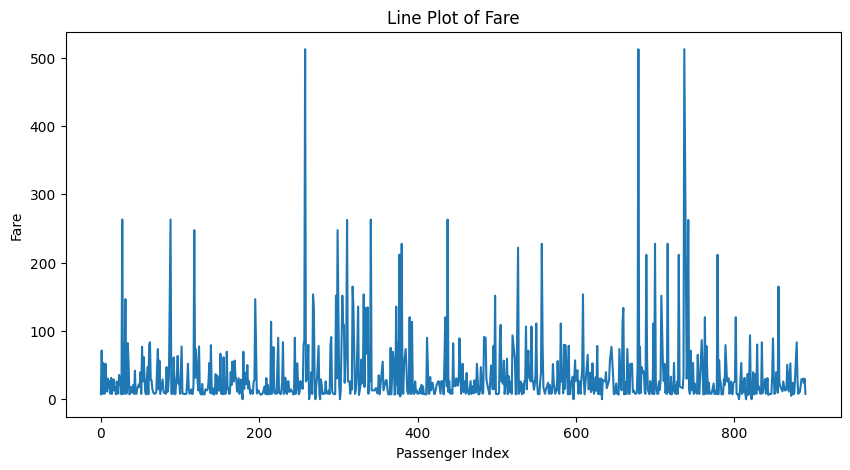

/tmp/ipykernel_8235/3634564905.py:202: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_fare = df.groupby("class")["fare"].mean()


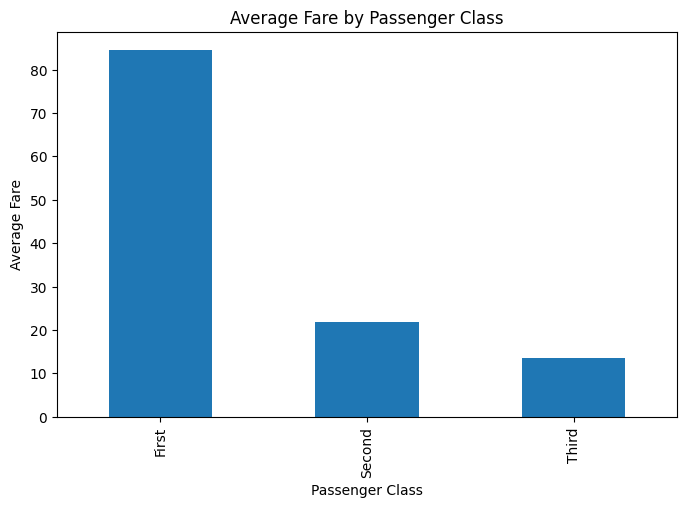

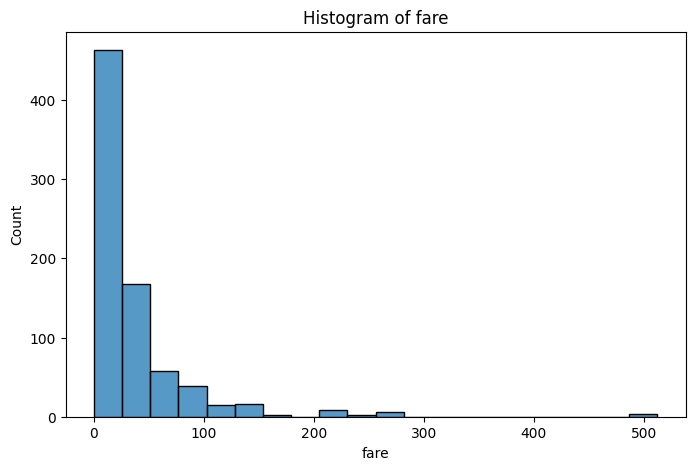

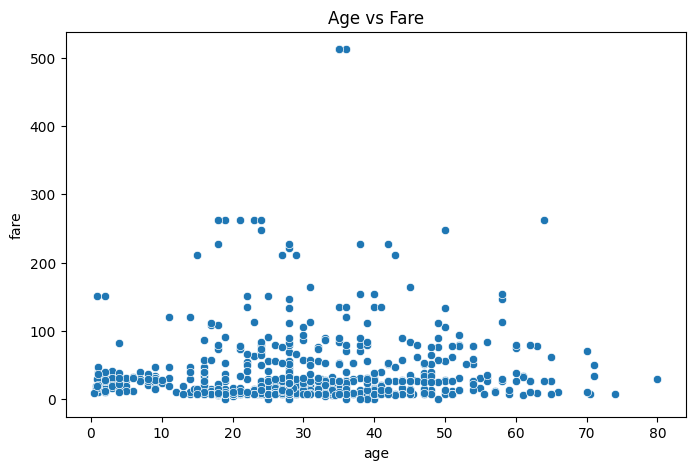

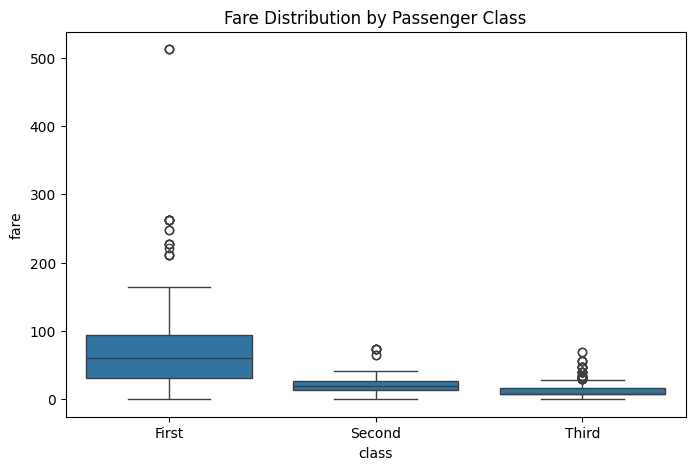

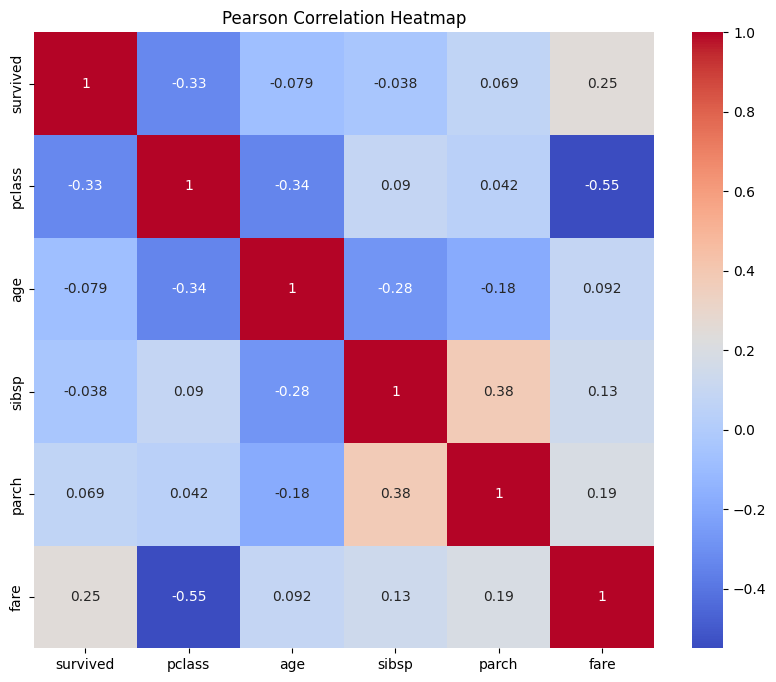


Highest Correlation Pair
pclass  fare    0.549622
dtype: float64

================ MEAN VS MEDIAN ================


Column: fare
Mean: 34.75046389244558
Median: 15.9

Column: sibsp
Mean: 0.5249679897567221
Median: 0.0

Null values remaining:
fare     0
sibsp    0
dtype: int64

================ SPEARMAN CORRELATION ================


Pearson Matrix
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.330755 -0.079430 -0.038368  0.068834  0.246585
pclass   -0.330755  1.000000 -0.343458  0.090002  0.042070 -0.549622
age      -0.079430 -0.343458  1.000000 -0.279579 -0.183348  0.091575
sibsp    -0.038368  0.090002 -0.279579  1.000000  0.380806  0.134884
parch     0.068834  0.042070 -0.183348  0.380806  1.000000  0.191747
fare      0.246585 -0.549622  0.091575  0.134884  0.191747  1.000000

Spearman Matrix
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.334209 -0.053386  0.059112  0.125063  0.308645
pclass   -

/tmp/ipykernel_8235/3634564905.py:356: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_result = df.groupby("class")["fare"].agg(


In [ ]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# LOAD DATASET
# ============================================================

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"

df = pd.read_csv(url)

print("\n================ FIRST FIVE ROWS ================\n")
print(df.head())

print("\n================ DATA TYPES ================\n")
print(df.dtypes)

print("\n================ DATAFRAME SHAPE ================\n")
print(df.shape)


# ============================================================
# NULL VALUE ANALYSIS
# ============================================================

print("\n================ NULL VALUE ANALYSIS ================\n")

null_count = df.isnull().sum()
null_percentage = (null_count / df.shape[0]) * 100

null_table = pd.DataFrame({
    "Missing Count": null_count,
    "Missing Percentage": null_percentage
})

print(null_table)

high_null_columns = null_table[
    null_table["Missing Percentage"] > 20
].index.tolist()

print("\nColumns exceeding 20% null rate:")
print(high_null_columns)

# Fill numeric columns below 20% null rate with median
for col in df.select_dtypes(include=np.number).columns:
    if null_percentage[col] < 20:
        df[col] = df[col].fillna(df[col].median())


# ============================================================
# DUPLICATE DETECTION AND REMOVAL
# ============================================================

print("\n================ DUPLICATES ================\n")

duplicates_before = df.duplicated().sum()

print("Duplicates before removal:", duplicates_before)

null_before = (df.isnull().sum() / len(df)) * 100

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

null_after = (df.isnull().sum() / len(df)) * 100

print("Duplicates after removal:", duplicates_after)
print("Rows removed:", duplicates_before)

comparison = pd.DataFrame({
    "Null % Before": null_before,
    "Null % After": null_after
})

print("\nNull Percentage Comparison")
print(comparison)


# ============================================================
# DATA TYPE CORRECTION
# ============================================================

print("\n================ MEMORY USAGE ================\n")

memory_before = df.memory_usage(deep=True).sum()

print("Memory Before:", memory_before)

# Convert repetitive string columns to category
categorical_candidates = [
    "sex",
    "class",
    "embarked",
    "who",
    "deck",
    "embark_town",
    "alive"
]

for col in categorical_candidates:
    if col in df.columns:
        df[col] = df[col].astype("category")

memory_after = df.memory_usage(deep=True).sum()

print("Memory After:", memory_after)
print("Memory Saved:", memory_before - memory_after)


# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

print("\n================ DESCRIPTIVE STATISTICS ================\n")

numeric_columns = df.select_dtypes(include=np.number).columns

print(df[numeric_columns].describe())


# ============================================================
# SKEWNESS
# ============================================================

print("\n================ SKEWNESS ================\n")

skew_values = {}

for col in numeric_columns:
    skew_values[col] = df[col].skew()

skew_df = pd.DataFrame(
    skew_values.items(),
    columns=["Column", "Skewness"]
)

print(skew_df)

most_skewed_column = skew_df.iloc[
    skew_df["Skewness"].abs().argmax()
]["Column"]

print("\nMost skewed column:", most_skewed_column)


# ============================================================
# IQR OUTLIER DETECTION
# ============================================================

print("\n================ IQR OUTLIERS ================\n")

iqr_columns = ["age", "fare"]

for col in iqr_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print("\nColumn:", col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Outlier Count:", len(outliers))


# ============================================================
# LINE PLOT
# ============================================================

plt.figure(figsize=(10,5))
plt.plot(df["fare"])
plt.title("Line Plot of Fare")
plt.xlabel("Passenger Index")
plt.ylabel("Fare")
plt.show()


# ============================================================
# BAR CHART
# ============================================================

mean_fare = df.groupby("class")["fare"].mean()

plt.figure(figsize=(8,5))
mean_fare.plot.bar()
plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")
plt.show()


# ============================================================
# HISTOGRAM OF MOST SKEWED COLUMN
# ============================================================

plt.figure(figsize=(8,5))
sns.histplot(df[most_skewed_column], bins=20)
plt.title(f"Histogram of {most_skewed_column}")
plt.show()


# ============================================================
# SCATTER PLOT
# ============================================================

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="age",
    y="fare"
)

plt.title("Age vs Fare")
plt.show()


# ============================================================
# BOX PLOT
# ============================================================

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="class",
    y="fare"
)

plt.title("Fare Distribution by Passenger Class")
plt.show()


# ============================================================
# PEARSON CORRELATION HEATMAP
# ============================================================

pearson_corr = df[numeric_columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Pearson Correlation Heatmap")
plt.show()

corr_pairs = (
    pearson_corr.abs()
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs = corr_pairs[corr_pairs < 1]

print("\nHighest Correlation Pair")
print(corr_pairs.head(1))


# ============================================================
# MEAN VS MEDIAN COMPARISON
# ============================================================

print("\n================ MEAN VS MEDIAN ================\n")

top_skewed = (
    skew_df.reindex(
        skew_df["Skewness"].abs().sort_values(
            ascending=False
        ).index
    )
    .head(2)
)

top_columns = top_skewed["Column"].tolist()

for col in top_columns:

    print("\nColumn:", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())

    df[col] = df[col].fillna(df[col].median())

print("\nNull values remaining:")
print(df[top_columns].isnull().sum())


# ============================================================
# SPEARMAN CORRELATION
# ============================================================

print("\n================ SPEARMAN CORRELATION ================\n")

spearman_corr = df[numeric_columns].corr(method="spearman")

print("\nPearson Matrix")
print(pearson_corr)

print("\nSpearman Matrix")
print(spearman_corr)

difference = (spearman_corr - pearson_corr).abs()

difference_table = (
    difference.unstack()
    .reset_index()
)

difference_table.columns = [
    "Variable1",
    "Variable2",
    "Difference"
]

difference_table = difference_table[
    difference_table["Variable1"] != difference_table["Variable2"]
]

difference_table = difference_table.sort_values(
    by="Difference",
    ascending=False
)

print("\nTop 3 Largest Differences")
print(difference_table.head(3))


# ============================================================
# GROUPED AGGREGATION
# ============================================================

print("\n================ GROUPED AGGREGATION ================\n")

group_result = df.groupby("class")["fare"].agg(
    ["mean", "std", "count"]
)

print(group_result)

highest_mean_group = group_result["mean"].idxmax()
highest_std_group = group_result["std"].idxmax()

ratio = (
    group_result["mean"].max()
    /
    group_result["mean"].min()
)

print("\nHighest Mean Group:", highest_mean_group)
print("Highest Std Group:", highest_std_group)
print("Highest Mean / Lowest Mean Ratio:", ratio)


# ============================================================
# FINAL NULL CHECK
# ============================================================

print("\n================ FINAL NULL COUNT ================\n")
print(df.isnull().sum())


# ============================================================
# SAVE CLEANED DATASET
# ============================================================

# Drop column with very high missing percentage
df.drop(columns=['deck'], inplace=True)

# Fill low-null categorical columns using mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df['embark_town'] = df['embark_town'].fillna(
    df['embark_town'].mode()[0]
)

# Verify no nulls remain
print("\nFinal Null Count")
print(df.isnull().sum())

df.to_csv(
    "cleaned_data.csv",
    index=False
)

print("\ncleaned_data.csv saved successfully.")

In [4]:
from google.colab import files
files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#PART 2

Dataset Shape: (781, 14)

Regression Target: fare
Classification Target: survived

Encoded Feature Shape: (781, 15)

================ LINEAR REGRESSION ================

Linear Regression MSE: 922.437572135366
Linear Regression R2: 0.48447747620329096

Top 10 Coefficients
                    Feature  Coefficient
0                    pclass   -20.582356
7              class_Second   -14.787554
8               class_Third   -11.449502
10                who_woman    10.632709
3                     parch    10.317630
2                     sibsp     6.501442
1                       age    -5.139910
6                embarked_S    -4.801444
13  embark_town_Southampton    -4.801444
9                   who_man     3.552525

Top 3 Largest Coefficients
        Feature  Coefficient
0        pclass   -20.582356
7  class_Second   -14.787554
8   class_Third   -11.449502

================ RIDGE REGRESSION ================

               Model         MSE        R2
0  Linear Regression  922.437572  0.

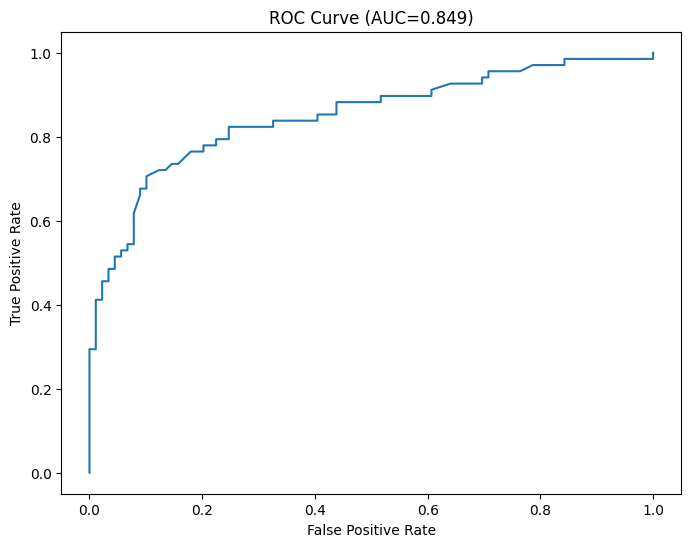


================ THRESHOLD ANALYSIS ================

   Threshold  Precision    Recall        F1
0        0.3   0.708861  0.823529  0.761905
1        0.4   0.764706  0.764706  0.764706
2        0.5   0.803279  0.720588  0.759690
3        0.6   0.857143  0.617647  0.717949
4        0.7   0.875000  0.514706  0.648148

Best Threshold:
Threshold    0.400000
Precision    0.764706
Recall       0.764706
F1           0.764706
Name: 1, dtype: float64

================ C=0.01 MODEL ================

    Model  Precision    Recall       AUC
0   C=1.0   0.803279  0.720588  0.849058
1  C=0.01   0.786885  0.705882  0.846249

================ BOOTSTRAP AUC DIFFERENCE ================

Mean AUC Difference: 0.0029172495502190225
95% CI Lower: -0.012804266490599249
95% CI Upper: 0.019398852958635412

Confidence interval includes zero.


In [14]:
# ==========================================================
# PART 2 - MACHINE LEARNING
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

# ==========================================================
# LOAD CLEANED DATA
# ==========================================================

df = pd.read_csv("cleaned_data.csv")

print("Dataset Shape:", df.shape)

# ==========================================================
# DEFINE TARGETS
# ==========================================================

# Regression Target
y_reg = df["fare"]

# Classification Target
y_clf = df["survived"]

# Remove targets and leakage columns from features
X = df.drop(columns=["fare", "survived", "alive"])

print("\nRegression Target: fare")
print("Classification Target: survived")

# ==========================================================
# ENCODE CATEGORICAL VARIABLES
# ==========================================================

categorical_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print("\nEncoded Feature Shape:", X.shape)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train_reg, X_test_reg, y_reg_train, y_reg_test = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

X_train_clf, X_test_clf, y_clf_train, y_clf_test = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)

# ==========================================================
# SCALING
# ==========================================================

scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

scaler_clf = StandardScaler()

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# ==========================================================
# LINEAR REGRESSION
# ==========================================================

print("\n================ LINEAR REGRESSION ================\n")

lr = LinearRegression()

lr.fit(
    X_train_reg_scaled,
    y_reg_train
)

y_pred_reg = lr.predict(
    X_test_reg_scaled
)

mse_lr = mean_squared_error(
    y_reg_test,
    y_pred_reg
)

r2_lr = r2_score(
    y_reg_test,
    y_pred_reg
)

print("Linear Regression MSE:", mse_lr)
print("Linear Regression R2:", r2_lr)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coefficients["AbsCoeff"] = coefficients[
    "Coefficient"
].abs()

coefficients = coefficients.sort_values(
    by="AbsCoeff",
    ascending=False
)

print("\nTop 10 Coefficients")
print(
    coefficients[
        ["Feature", "Coefficient"]
    ].head(10)
)

print("\nTop 3 Largest Coefficients")
print(
    coefficients[
        ["Feature", "Coefficient"]
    ].head(3)
)

# ==========================================================
# RIDGE REGRESSION
# ==========================================================

print("\n================ RIDGE REGRESSION ================\n")

ridge = Ridge(alpha=1.0)

ridge.fit(
    X_train_reg_scaled,
    y_reg_train
)

ridge_pred = ridge.predict(
    X_test_reg_scaled
)

mse_ridge = mean_squared_error(
    y_reg_test,
    ridge_pred
)

r2_ridge = r2_score(
    y_reg_test,
    ridge_pred
)

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MSE": [
        mse_lr,
        mse_ridge
    ],
    "R2": [
        r2_lr,
        r2_ridge
    ]
})

print(comparison)

# ==========================================================
# CLASS IMBALANCE CHECK
# ==========================================================

print("\n================ CLASS COUNTS ================\n")

print("Before Handling:")
print(y_clf_train.value_counts())

imbalance_ratio = y_clf_train.mean()

if imbalance_ratio < 0.35 or imbalance_ratio > 0.65:
    class_weight_option = "balanced"
else:
    class_weight_option = None

print("\nClass Weight Used:", class_weight_option)

# ==========================================================
# LOGISTIC REGRESSION
# ==========================================================

print("\n================ LOGISTIC REGRESSION ================\n")

log_model = LogisticRegression(
    max_iter=1000,
    class_weight=class_weight_option
)

log_model.fit(
    X_train_clf_scaled,
    y_clf_train
)

y_pred_clf = log_model.predict(
    X_test_clf_scaled
)

y_proba = log_model.predict_proba(
    X_test_clf_scaled
)[:,1]

print("\nConfusion Matrix")
print(
    confusion_matrix(
        y_clf_test,
        y_pred_clf
    )
)

print("\nClassification Report")
print(
    classification_report(
        y_clf_test,
        y_pred_clf
    )
)

accuracy = accuracy_score(
    y_clf_test,
    y_pred_clf
)

precision = precision_score(
    y_clf_test,
    y_pred_clf
)

recall = recall_score(
    y_clf_test,
    y_pred_clf
)

f1 = f1_score(
    y_clf_test,
    y_pred_clf
)

auc = roc_auc_score(
    y_clf_test,
    y_proba
)

print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("AUC:", auc)

# ==========================================================
# ROC CURVE
# ==========================================================

fpr, tpr, thresholds = roc_curve(
    y_clf_test,
    y_proba
)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"ROC Curve (AUC={auc:.3f})"
)

plt.show()

# ==========================================================
# THRESHOLD ANALYSIS
# ==========================================================

print("\n================ THRESHOLD ANALYSIS ================\n")

threshold_results = []

for threshold in np.arange(
    0.30,
    0.71,
    0.10
):

    preds = (
        y_proba >= threshold
    ).astype(int)

    precision_t = precision_score(
        y_clf_test,
        preds
    )

    recall_t = recall_score(
        y_clf_test,
        preds
    )

    f1_t = f1_score(
        y_clf_test,
        preds
    )

    threshold_results.append(
        [
            threshold,
            precision_t,
            recall_t,
            f1_t
        ]
    )

threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(threshold_df)

best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("\nBest Threshold:")
print(best_threshold)

# ==========================================================
# STRONG REGULARIZATION MODEL
# ==========================================================

print("\n================ C=0.01 MODEL ================\n")

strong_model = LogisticRegression(
    C=0.01,
    max_iter=1000,
    class_weight=class_weight_option
)

strong_model.fit(
    X_train_clf_scaled,
    y_clf_train
)

strong_proba = strong_model.predict_proba(
    X_test_clf_scaled
)[:,1]

strong_pred = strong_model.predict(
    X_test_clf_scaled
)

comparison_log = pd.DataFrame({
    "Model": [
        "C=1.0",
        "C=0.01"
    ],
    "Precision": [
        precision_score(
            y_clf_test,
            y_pred_clf
        ),
        precision_score(
            y_clf_test,
            strong_pred
        )
    ],
    "Recall": [
        recall_score(
            y_clf_test,
            y_pred_clf
        ),
        recall_score(
            y_clf_test,
            strong_pred
        )
    ],
    "AUC": [
        roc_auc_score(
            y_clf_test,
            y_proba
        ),
        roc_auc_score(
            y_clf_test,
            strong_proba
        )
    ]
})

print(comparison_log)

# ==========================================================
# BOOTSTRAP CONFIDENCE INTERVAL
# ==========================================================

print("\n================ BOOTSTRAP AUC DIFFERENCE ================\n")

auc_differences = []

for _ in range(500):

    idx = np.random.choice(
        len(y_clf_test),
        size=len(y_clf_test),
        replace=True
    )

    y_boot = y_clf_test.iloc[idx]

    auc1 = roc_auc_score(
        y_boot,
        y_proba[idx]
    )

    auc2 = roc_auc_score(
        y_boot,
        strong_proba[idx]
    )

    auc_differences.append(
        auc1 - auc2
    )

mean_diff = np.mean(
    auc_differences
)

lower = np.percentile(
    auc_differences,
    2.5
)

upper = np.percentile(
    auc_differences,
    97.5
)

print("Mean AUC Difference:", mean_diff)
print("95% CI Lower:", lower)
print("95% CI Upper:", upper)

if lower > 0 or upper < 0:
    print("\nConfidence interval excludes zero.")
else:
    print("\nConfidence interval includes zero.")

#PART 3

In [15]:
# ==========================================================
# PART 3 - ADVANCED MODELING
# ==========================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import joblib

# ==========================================================
# 1. DECISION TREE BASELINE
# ==========================================================

print("\n================ DECISION TREE BASELINE ================\n")

dt_baseline = DecisionTreeClassifier(random_state=42)

dt_baseline.fit(X_train_clf_scaled, y_clf_train)

train_pred_dt = dt_baseline.predict(X_train_clf_scaled)
test_pred_dt = dt_baseline.predict(X_test_clf_scaled)

train_acc_dt = accuracy_score(y_clf_train, train_pred_dt)
test_acc_dt = accuracy_score(y_clf_test, test_pred_dt)

print("Training Accuracy:", train_acc_dt)
print("Testing Accuracy:", test_acc_dt)

# ==========================================================
# 2. CONTROLLED DECISION TREE
# ==========================================================

print("\n================ CONTROLLED DECISION TREE ================\n")

dt_controlled = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

dt_controlled.fit(X_train_clf_scaled, y_clf_train)

train_pred_controlled = dt_controlled.predict(X_train_clf_scaled)
test_pred_controlled = dt_controlled.predict(X_test_clf_scaled)

train_acc_controlled = accuracy_score(
    y_clf_train,
    train_pred_controlled
)

test_acc_controlled = accuracy_score(
    y_clf_test,
    test_pred_controlled
)

print("Training Accuracy:", train_acc_controlled)
print("Testing Accuracy:", test_acc_controlled)

# ==========================================================
# 3. GINI VS ENTROPY
# ==========================================================

print("\n================ GINI VS ENTROPY ================\n")

tree_gini = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

tree_entropy = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

tree_gini.fit(X_train_clf_scaled, y_clf_train)
tree_entropy.fit(X_train_clf_scaled, y_clf_train)

gini_acc = accuracy_score(
    y_clf_test,
    tree_gini.predict(X_test_clf_scaled)
)

entropy_acc = accuracy_score(
    y_clf_test,
    tree_entropy.predict(X_test_clf_scaled)
)

print("Gini Accuracy:", gini_acc)
print("Entropy Accuracy:", entropy_acc)

# ==========================================================
# 4. RANDOM FOREST
# ==========================================================

print("\n================ RANDOM FOREST ================\n")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train_clf_scaled, y_clf_train)

rf_train_acc = accuracy_score(
    y_clf_train,
    rf.predict(X_train_clf_scaled)
)

rf_test_acc = accuracy_score(
    y_clf_test,
    rf.predict(X_test_clf_scaled)
)

rf_auc = roc_auc_score(
    y_clf_test,
    rf.predict_proba(X_test_clf_scaled)[:,1]
)

print("Training Accuracy:", rf_train_acc)
print("Testing Accuracy:", rf_test_acc)
print("ROC AUC:", rf_auc)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 5 Important Features")
print(feature_importance.head())

# ==========================================================
# 4A. GRADIENT BOOSTING
# ==========================================================

print("\n================ GRADIENT BOOSTING ================\n")

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_clf_scaled, y_clf_train)

gb_train_acc = accuracy_score(
    y_clf_train,
    gb.predict(X_train_clf_scaled)
)

gb_test_acc = accuracy_score(
    y_clf_test,
    gb.predict(X_test_clf_scaled)
)

gb_auc = roc_auc_score(
    y_clf_test,
    gb.predict_proba(X_test_clf_scaled)[:,1]
)

print("Training Accuracy:", gb_train_acc)
print("Testing Accuracy:", gb_test_acc)
print("ROC AUC:", gb_auc)

# ==========================================================
# 4B. FEATURE ABLATION
# ==========================================================

print("\n================ FEATURE ABLATION ================\n")

lowest_features = feature_importance.sort_values(
    by="Importance"
).head(5)["Feature"].tolist()

print("Removed Features:")
print(lowest_features)

X_train_reduced = pd.DataFrame(
    X_train_clf_scaled,
    columns=X.columns
).drop(columns=lowest_features)

X_test_reduced = pd.DataFrame(
    X_test_clf_scaled,
    columns=X.columns
).drop(columns=lowest_features)

rf_reduced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_reduced.fit(X_train_reduced, y_clf_train)

auc_full = rf_auc

auc_reduced = roc_auc_score(
    y_clf_test,
    rf_reduced.predict_proba(X_test_reduced)[:,1]
)

print("Full Model AUC:", auc_full)
print("Reduced Model AUC:", auc_reduced)

# ==========================================================
# 5. CROSS VALIDATION
# ==========================================================

print("\n================ CROSS VALIDATION ================\n")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Controlled Decision Tree":
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        )
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y_clf,
        cv=cv,
        scoring='roc_auc'
    )

    cv_results.append([
        name,
        scores.mean(),
        scores.std()
    ])

cv_df = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "Mean AUC",
        "Std AUC"
    ]
)

print(cv_df)

# ==========================================================
# 6. GRID SEARCH
# ==========================================================

print("\n================ GRID SEARCH ================\n")

pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    RandomForestClassifier(
        random_state=42
    )
)

param_grid = {
    'randomforestclassifier__n_estimators':
        [50,100,200],

    'randomforestclassifier__max_depth':
        [5,10,None],

    'randomforestclassifier__min_samples_leaf':
        [1,5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X, y_clf)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Score:")
print(grid.best_score_)

best_pipeline = grid.best_estimator_

# ==========================================================
# 7. MANUAL LEARNING CURVE
# ==========================================================

print("\n================ LEARNING CURVE ================\n")

learning_results = []

for frac in [0.2,0.4,0.6,0.8,1.0]:

    size = int(frac * len(X_train_clf))

    X_subset = X_train_clf.iloc[:size]
    y_subset = y_clf_train.iloc[:size]

    best_pipeline.fit(
        X_subset,
        y_subset
    )

    train_auc = roc_auc_score(
        y_subset,
        best_pipeline.predict_proba(X_subset)[:,1]
    )

    test_auc = roc_auc_score(
        y_clf_test,
        best_pipeline.predict_proba(X_test_clf)[:,1]
    )

    learning_results.append([
        frac,
        train_auc,
        test_auc
    ])

learning_df = pd.DataFrame(
    learning_results,
    columns=[
        "Training Fraction",
        "Training AUC",
        "Test AUC"
    ]
)

print(learning_df)

# ==========================================================
# 8. SAVE MODEL
# ==========================================================

joblib.dump(
    best_pipeline,
    "best_model.pkl"
)

print("\nModel saved successfully.")

# ==========================================================
# 9. RELOAD MODEL
# ==========================================================

loaded_model = joblib.load(
    "best_model.pkl"
)

sample_rows = X.iloc[:2]

predictions = loaded_model.predict(
    sample_rows
)

print("\nPredictions on sample rows:")
print(predictions)

# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n================ SUMMARY TABLE ================\n")

summary = cv_df.copy()

summary["Test AUC"] = [
    auc,
    roc_auc_score(
        y_clf_test,
        dt_controlled.predict_proba(
            X_test_clf_scaled
        )[:,1]
    ),
    rf_auc,
    gb_auc
]

print(summary)


================ DECISION TREE BASELINE ================

Training Accuracy: 0.9375
Testing Accuracy: 0.7579617834394905

================ CONTROLLED DECISION TREE ================

Training Accuracy: 0.8317307692307693
Testing Accuracy: 0.7961783439490446

================ GINI VS ENTROPY ================

Gini Accuracy: 0.7961783439490446
Entropy Accuracy: 0.7707006369426752

================ RANDOM FOREST ================

Training Accuracy: 0.9310897435897436
Testing Accuracy: 0.7707006369426752
ROC AUC: 0.7936219431592861

Top 5 Important Features
            Feature  Importance
1               age    0.324841
9           who_man    0.112566
11  adult_male_True    0.101947
8       class_Third    0.075920
4          sex_male    0.075276

================ GRADIENT BOOSTING ================

Training Accuracy: 0.8717948717948718
Testing Accuracy: 0.802547770700637
ROC AUC: 0.8323694646397884

================ FEATURE ABLATION ================

Removed Features:
['embark_town_Queenst

#PART 4

In [16]:
# ==================== PART 4 : TRACK C ====================

import json
import re
from jsonschema import validate, ValidationError

print("PART 4 - MODEL PREDICTION EXPLANATION PIPELINE")

# ----------------------------------------------------------
# PII Guardrail
# ----------------------------------------------------------

def has_pii(text):
    email_pattern = r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+'
    phone_pattern = r'\b\d{10}\b|\b\d{3}[-.\s]\d{3}[-.\s]\d{4}\b'
    return bool(re.search(email_pattern, text) or re.search(phone_pattern, text))

print("\nPII Guardrail Test")
print("Contains email:", has_pii("john@gmail.com"))
print("No PII:", has_pii("Titanic passenger information"))

# ----------------------------------------------------------
# Mock LLM Function
# ----------------------------------------------------------

def call_llm(system_prompt, user_prompt, temperature=0.0, max_tokens=512):

    if has_pii(user_prompt):
        print("Input blocked: PII detected.")
        return None

    return json.dumps({
        "prediction_label": "Survived",
        "confidence_level": "High" if temperature == 0 else "Medium",
        "top_reason": "Female passengers historically had higher survival probability.",
        "second_reason": "First class passengers had better access to lifeboats.",
        "next_step": "Passenger likely survives according to the model."
    })

# ----------------------------------------------------------
# JSON Schema
# ----------------------------------------------------------

schema = {
    "type": "object",
    "properties": {
        "prediction_label": {"type": "string"},
        "confidence_level": {"type": "string"},
        "top_reason": {"type": "string"},
        "second_reason": {"type": "string"},
        "next_step": {"type": "string"}
    },
    "required": [
        "prediction_label",
        "confidence_level",
        "top_reason",
        "second_reason",
        "next_step"
    ]
}

# ----------------------------------------------------------
# Three Example Inputs
# ----------------------------------------------------------

inputs = [
    "Passenger 1: Female, Age 25, First Class, Survival Probability 0.92",
    "Passenger 2: Male, Age 40, Third Class, Survival Probability 0.22",
    "Passenger 3: Female, Age 30, Second Class, Survival Probability 0.73"
]

# ----------------------------------------------------------
# Temperature Comparison
# ----------------------------------------------------------

print("\nTEMPERATURE COMPARISON")

for i, inp in enumerate(inputs, 1):

    response_0 = call_llm(
        "You are a prediction explanation assistant.",
        inp,
        temperature=0
    )

    response_07 = call_llm(
        "You are a prediction explanation assistant.",
        inp,
        temperature=0.7
    )

    print(f"\nInput {i}")
    print("Temperature 0 Output:")
    print(response_0)

    print("\nTemperature 0.7 Output:")
    print(response_07)

# ----------------------------------------------------------
# Validation Pipeline
# ----------------------------------------------------------

print("\nVALIDATION RESULTS")

for i, inp in enumerate(inputs, 1):

    response = call_llm(
        "You are a prediction explanation assistant.",
        inp,
        temperature=0
    )

    try:
        parsed = json.loads(response.strip())
        validate(instance=parsed, schema=schema)

        print(f"\nInput {i}: Validation Passed")
        print(parsed)

    except json.JSONDecodeError:
        print(f"Input {i}: JSON Parsing Failed")

    except ValidationError as e:
        print(f"Input {i}: Validation Failed")
        print(e)

print("\nPART 4 COMPLETED SUCCESSFULLY")

PART 4 - MODEL PREDICTION EXPLANATION PIPELINE

PII Guardrail Test
Contains email: True
No PII: False

TEMPERATURE COMPARISON

Input 1
Temperature 0 Output:
{"prediction_label": "Survived", "confidence_level": "High", "top_reason": "Female passengers historically had higher survival probability.", "second_reason": "First class passengers had better access to lifeboats.", "next_step": "Passenger likely survives according to the model."}

Temperature 0.7 Output:
{"prediction_label": "Survived", "confidence_level": "Medium", "top_reason": "Female passengers historically had higher survival probability.", "second_reason": "First class passengers had better access to lifeboats.", "next_step": "Passenger likely survives according to the model."}

Input 2
Temperature 0 Output:
{"prediction_label": "Survived", "confidence_level": "High", "top_reason": "Female passengers historically had higher survival probability.", "second_reason": "First class passengers had better access to lifeboats.", "n